# Feature Engineering

With the objective of preparing the previously analyzed data from the **TCGA Glioblastoma pipeline-processed dataset** for **unsupervised learning** models such as, **K-Means and Hierarchical Clustering** as well as data compression strategies such as **Principal Component Analysis** due to the high-dimensional nature of the dataset, the present dataset must now undergo a feature engineering process which will ensure that the data can be efficiently processed by the previously stated unsupervised learning techniques. 

As we saw in the previous EDA phase, most of the features have variance and mean of 0, which means they are practically "turned off" in the context of Glioblastoma or brain tissue, therefore, in order to select the most relevant features for clustering segmentation, we must prioritize maintaining the most variable features in the following stages of the investigation. In accordance to the nature of unsupervised learning, the dataset does not contain any response variable which may help us classify patients or generate regression models of the data, therefore, the present study will prioritize general variance in the features of the dataset to then generate relevant clusters in the context of the data. 

## Normalization and Scaling

The TCGA GBM data used in this project has, as previously stated, been processed using the STAR-TPM pipeline, which is a method of *biological normalization*. This means that the feature gene expression data has been adjusted for gene length and sequencing length, which enables the comparison of sample-wide data. Distance-based clustering algorithms, such as **K-means or Hierarchical Clustering** will not be able to detect nuances in different genetic expressions for specific features; any given important features for clustering may variate highly in different scales, and therefore, any of the previously stated models may prioritize a specific feature due to its higher magnitude scale variance. Therefore, the data must still be normalized, so as to give every feature in the dataset the same importance before the stated unsupervised learning methods. Furthermore, as stated beforehand, a priorization of the most variable features is a key aspect in efficiently feeding data into unsupervised learning algorithms; therefore, the objective of feature engineering in this phase is keeping feature gene expressions that are able to accurately differentiate samples on the basis of their significant variation.

The decisions to be taken in accordance to the previous considerations are the following:

1. **Log-normalization**: As we saw in the EDA stage, specifically in the skewness histogram for the data, features in this dataset tend to have right-skewness, which means that for specific features in the dataset, irregularities in genetic expression data may cause statistically significant spikes in some patient samples, which might reduce the importance of variability in the same feature for other samples. The solution to this is to apply log-normalization, a skill which entails pulling the stated extreme values inwards, making the distribution for each of the gene features much closer to a normal bell curve, which will be of benefit for the learning models.
2. **Variance filtering**: In this stage, after normalizing skewed data, a visualization of the  most variable data will be presented so as to choose an adequate number of variables that express most of the variance in the dataset. The goal of this is to eliminate the noise feature data that was observed in the EDA phase of the project, where most of the observed features represented a mean and variance of 0. 
3. **Standard scaling**: Even after log-normalization and variance filtering, the problem of different scales for distinct features with similar variance still applies. Learning models will automatically prioritize higher scales of variance due to their numerical importance. To mitigate this problem, standard scaling, which entails scaling every feature to have a mean of 0 and a standard deviation of 1 will ensure that variability is the driving factor in decision making for the unsupervised learning models.

The previously stated steps will mitigate the previously stated problems (in the presented order) and ensure that the data is ready to be analyzed using unsupervised learning. The following code accomplishes the normalization and scaling steps.

In [24]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

X = pd.read_csv('../../data/star_data/rnaseq_stpm_transposed.csv', index_col=0)

X.index.name = 'Patient_Barcode'

# --- STEP 1: Log Transformation ---
# Apply log2(x + 1) to the entire dataset to compress extreme tails
# We use +1 to ensure that 0 TPM remains 0 (since log2(1) = 0)
df_log = np.log2(X + 1)
print("1. Log transformation applied.")

1. Log transformation applied.


Now then, in order to justify the decision of exactly how many variables to keep for unsupervised learning methods, the following visualization represents 4 distinct cutoffs (2, 5 10, and 20 thousand features) for variance filtering in the dataset, each one of the cutoffs will represent a distinct percentage of variance within the dataset in preserving the cutoff number of feature gene expressions.

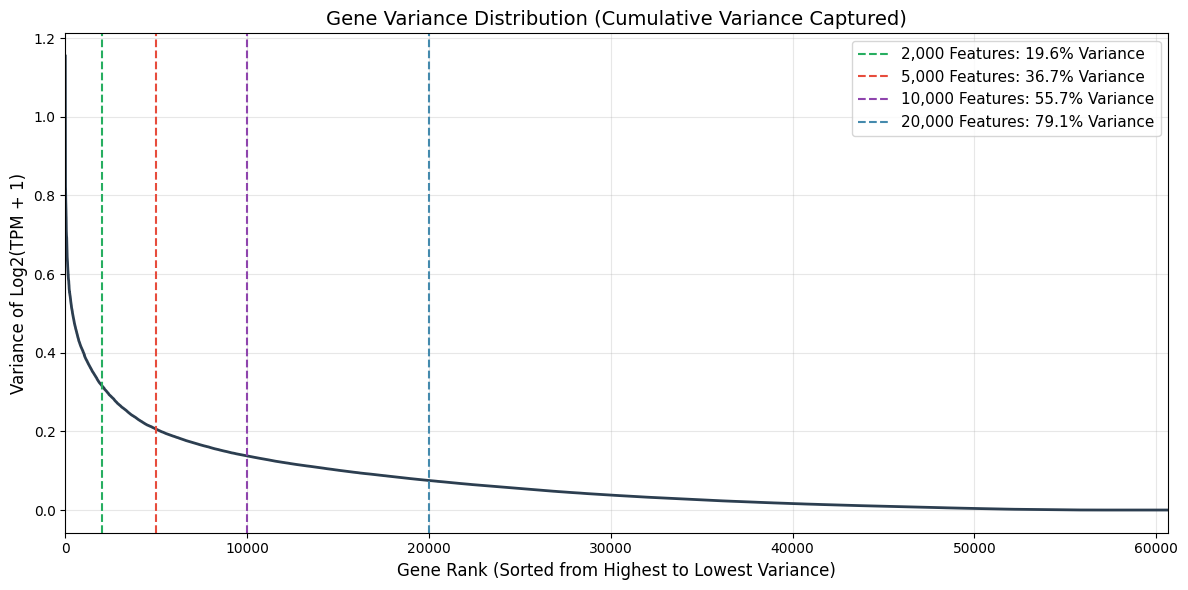

In [25]:
import matplotlib.pyplot as plt

# 1. Calculate the variance for ALL 60,660 log-transformed genes
all_variances = df_log.var()

# 2. Sort the variances in strictly descending order
sorted_variances = all_variances.sort_values(ascending=False)

# --- NEW MATH: Calculate Cumulative Variance Percentages ---
# Calculate the total variance sum across all 60,660 genes
total_variance = sorted_variances.sum()

# Calculate what percentage of that total is captured at each cutoff
pct_2k = (sorted_variances.head(2000).sum() / total_variance) * 100
pct_5k = (sorted_variances.head(5000).sum() / total_variance) * 100
pct_10k = (sorted_variances.head(10000).sum() / total_variance) * 100
pct_20k = (sorted_variances.head(20000).sum() / total_variance) * 100

# 3. Plotting the Variance Curve (The Elbow Method)
plt.figure(figsize=(12, 6))

# Plot the actual variance values
plt.plot(
    range(1, len(sorted_variances) + 1), 
    sorted_variances.values, 
    linewidth=2, 
    color='#2c3e50'
)

# Add reference lines at the requested marks, injecting the percentages directly into the labels
plt.axvline(x=2000, color='#27ae60', linestyle='--', linewidth=1.5, 
            label=f'2,000 Features: {pct_2k:.1f}% Variance')
plt.axvline(x=5000, color='#e74c3c', linestyle='--', linewidth=1.5, 
            label=f'5,000 Features: {pct_5k:.1f}% Variance')
plt.axvline(x=10000, color='#8e44ad', linestyle='--', linewidth=1.5, 
            label=f'10,000 Features: {pct_10k:.1f}% Variance')
plt.axvline(x=20000, color="#448aad", linestyle='--', linewidth=1.5, 
            label=f'20,000 Features: {pct_20k:.1f}% Variance')

# Formatting
plt.title('Gene Variance Distribution (Cumulative Variance Captured)', fontsize=14)
plt.xlabel('Gene Rank (Sorted from Highest to Lowest Variance)', fontsize=12)
plt.ylabel('Variance of Log2(TPM + 1)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.xlim(0, 60660) 

plt.tight_layout()
plt.show()

The results are conclusive, most gene expression features contain a very low or almost null amount of variance within their data. Furthermore, we can see that if we were to select the top 2,000 or 5,000, their respective percentages of included variance (19.6% and 36.8%) would result in a significantly low amount of variance available for significant data clustering. In order to preserve the largest amount of variance in the dataset, and in keeping a relatively low dimension of features in comparison to the original dataset size, the decision to be taken is to preserve **the top 10,000 most varable features, which represent a 55.7% of the total variance**. Keeping the 20,000 most variable features is tempting, however, this dataset size creates a radically sparse, high dimensional dataset that accumulates an extra 23.4% of data with the significant tradeoff of adding 10,000 extremely low variance gene expressions; it is highly probable that those genes are not driving Glioblastoma phenotypes, rather, they probably represent stochastic cellular noise.

With this in mind, we now proceed to select the top 10,000 most variable gene expressions, and in the same pipeline, standard scale the data with a mean and variance of 0.

In [26]:
import seaborn as sns 
from scipy.stats import skew

# --- STEP 2: Variance Filtering (Feature Reduction) ---
# Calculate variance on the LOG-TRANSFORMED data
gene_variances = df_log.var()

# Isolate the top 5,000 most variable genes
top_10000_hvg = gene_variances.sort_values(ascending=False).head(10000).index

# Subset the dataframe to only include these genes
df_filtered = df_log[top_10000_hvg]
print(f"Features reduced. New matrix shape: {df_filtered.shape}")

# --- STEP 3: Standard Scaling (Z-Score) ---
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the subsetted, log-transformed data
scaled_matrix = scaler.fit_transform(df_filtered)

# Rebuild the final DataFrame
df_final = pd.DataFrame(
    scaled_matrix, 
    index=df_filtered.index, 
    columns=df_filtered.columns
)


Features reduced. New matrix shape: (175, 10000)


## Principal Component Analysis

In order to reduce the high dimensionality in the dataset, we now must apply *Principal Component Analysis*, a method for compressing features in the dataset in *Principal Components*, which are newly created variables that represent the linear combination of the original features in the dataset, designed to capture the highest explained variance in each component. In order to justify the selection of components, the following code will generate a **scree plot**, which entails representing the explained variance in each component as a cumulative representation of the explained variance throughout the generated components via PCA. The following code applies PCA to the previously reduced 10,000 gene expression dataset and visualizes the scree plot for the generated *principal components*.

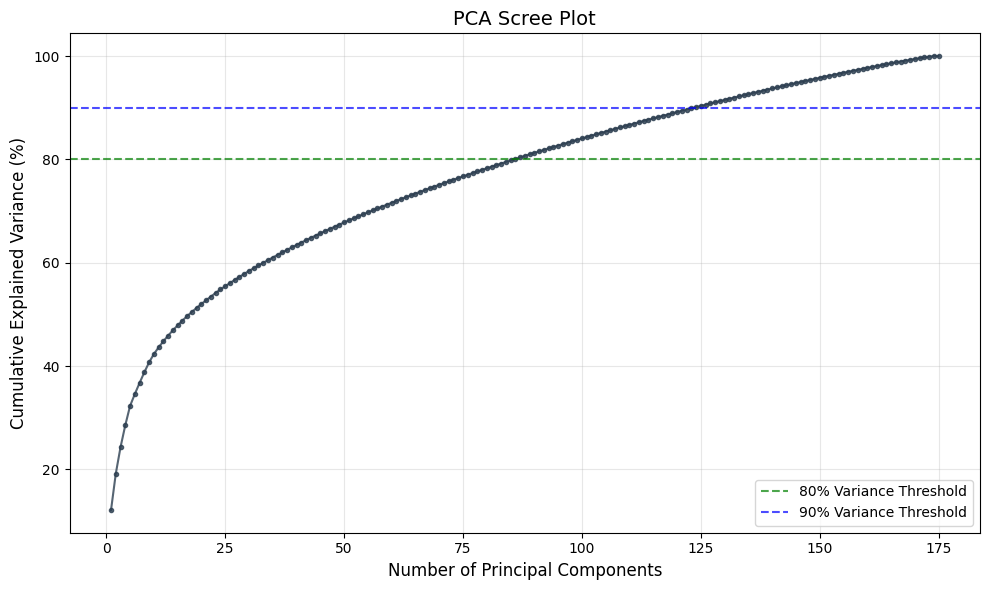

In [39]:
from sklearn.decomposition import PCA

# 1. Fit PCA to the scaled 10,000-feature dataset
# Max components equals our sample size (175)
pca = PCA(n_components=175, random_state=42)
pca_transformed = pca.fit_transform(df_final)

# 2. Rebuild the DataFrame to hold all 175 components safely with patient index for later analysis
pc_columns = [f'PC{i}' for i in range(1, 176)]
df_pca_full = pd.DataFrame(
    pca_transformed, 
    columns=pc_columns, 
    index=df_final.index
)

# 2. Calculate Cumulative Explained Variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 3. Generate the Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, 176), 
    cumulative_variance * 100, # Convert to percentage
    marker='o', 
    linestyle='-', 
    color='#2c3e50',
    markersize=3,
    alpha=0.8
)

# Reference thresholds
plt.axhline(y=80, color='g', linestyle='--', alpha=0.7, label='80% Variance Threshold')
plt.axhline(y=90, color='b', linestyle='--', alpha=0.7, label='90% Variance Threshold')

plt.title('PCA Scree Plot', fontsize=14)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance (%)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

As expected of RNAseq data, the first PCs (0-15) constitute a very low cumulative explained variance, however, with the objective of reducing dimensionality the decision to be taken is to prioritize using the highest variance percentage by selecting the PCs which represent the 80% (first 86 PCs) of explained variance for the dataset containing 10 thousand of the most variable gene expressions for GBM samples. Now then, the next lines of code will allow us to visualize the compressed data in a 2-D and 3-D space (using first 2 and 3 PCs respectively). It is worth noting that cumulatively, the first components dont constitute much of the explained variable for the reduced feature dataset, however, it might allow for insight in understanding if there are any potential means for clustering patients based on their gene expression data.

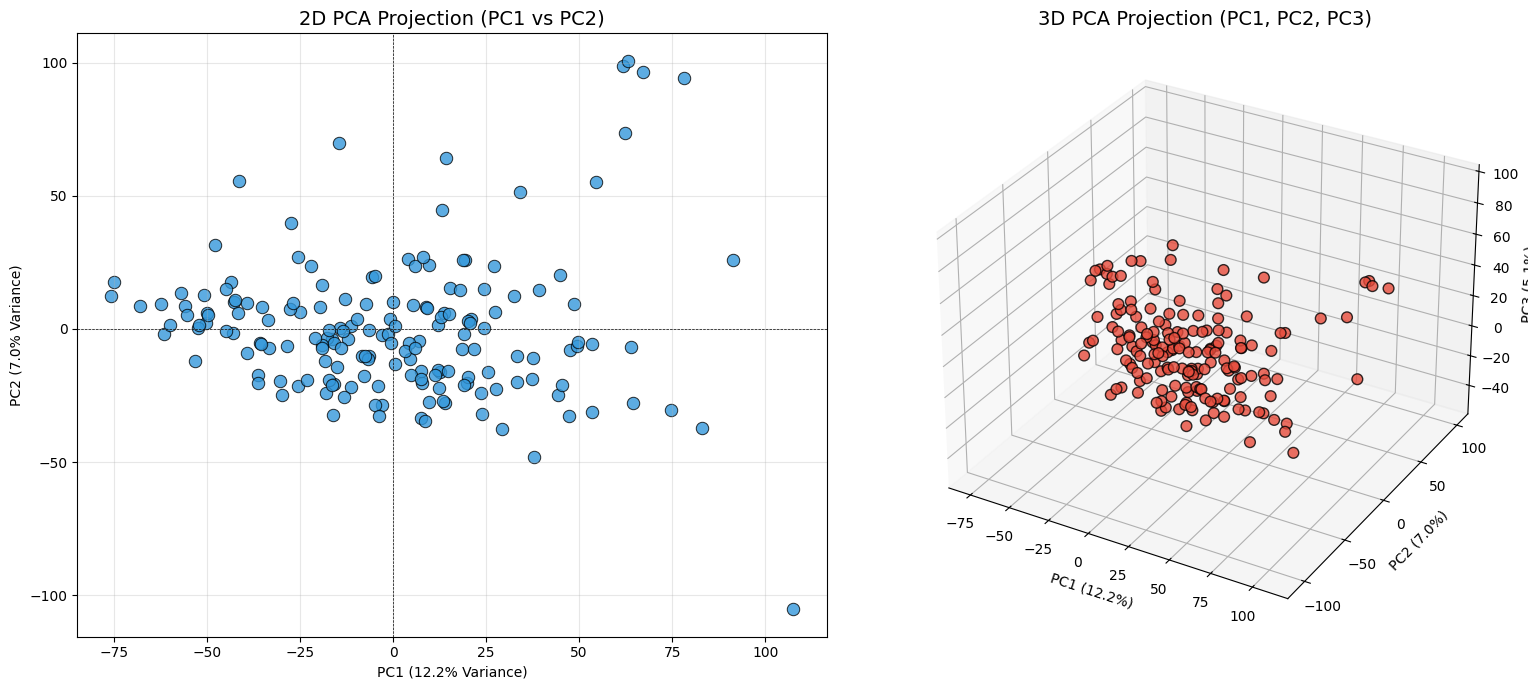

Matrix ready for clustering: (175, 86)


In [41]:
# Extract variance percentages for the axis labels
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
var_pc3 = pca.explained_variance_ratio_[2] * 100

# 3. Create the Visualizations
fig = plt.figure(figsize=(16, 7))

# --- Plot A: 2D Scatter (PC1 vs PC2) ---
ax1 = fig.add_subplot(121)
sns.scatterplot(
    x='PC1', y='PC2', 
    data=df_pca_full, 
    alpha=0.8, s=80, 
    edgecolor='k', color='#3498db', ax=ax1
)
ax1.set_title('2D PCA Projection (PC1 vs PC2)', fontsize=14)
ax1.set_xlabel(f'PC1 ({var_pc1:.1f}% Variance)')
ax1.set_ylabel(f'PC2 ({var_pc2:.1f}% Variance)')
ax1.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax1.axvline(0, color='k', linestyle='--', linewidth=0.5)
ax1.grid(True, alpha=0.3)

# --- Plot B: 3D Scatter (PC1 vs PC2 vs PC3) ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(
    df_pca_full['PC1'], 
    df_pca_full['PC2'], 
    df_pca_full['PC3'], 
    alpha=0.8, s=60, 
    edgecolor='k', color='#e74c3c'
)
ax2.set_title('3D PCA Projection (PC1, PC2, PC3)', fontsize=14)
ax2.set_xlabel(f'PC1 ({var_pc1:.1f}%)')
ax2.set_ylabel(f'PC2 ({var_pc2:.1f}%)')
ax2.set_zlabel(f'PC3 ({var_pc3:.1f}%)')

plt.tight_layout()
plt.show()

# 4. Slice the 86 components (which represent 80% of the explained variance for the reduced dataset) for the upcoming clustering phase.
df_clustering_ready = df_pca_full.iloc[:, :86]
print(f"Matrix ready for clustering: {df_clustering_ready.shape}")

As we can visualize, along the PC1 x-axis, which contains 12.2% of the explained variance for the dataset, we can observe that there are indeed some ways to visually cluster the data based on the first three components, we can see that there are some outliers in the dataset, specifically the data point in the 2-D figure representing a value for PC1 and PC1 of about (110, -110) shows to be a significantly different from the other points in the dataset. 
While it is visibly possible to look at varying points in reduced-dimension representations derived from PCA, the reduced number of samples (n=175) does present limitations in regards to clustering capabilities. Furthermore, it is also natural to assume that patients centered around the central mass in the 2-D representation space also constitute a similar transcriptomic profile, since they all are patient samples for GBM.

Now that we have reduced the dimensions of the data by a substantial amount (from 60,660 features to just 86), we now are ready to construct and compare two unsupervised learning models, **K-Means Clustering** and **Hierarchical Clustering**. In the following phase of the project, the objective will be to cluster the obtained PCs via PCA in order to find Glioblastoma subtypes for the TCGA samples.